<a href="https://colab.research.google.com/github/AkshatkMalik/python-data-science-toolkit/blob/main/cardiotocography_eda_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**ASSIGNMENT-5**

**EXPLORATORY DATA ANALYSIS ON A DATASET**

**Step 1: Loading and Cleaning the Data**

What we are doing:

In order to be able to analyze the given dataset, we must import it first in the Python environment and clean it up. This is because actual datasets are messy datasets that can contain empty cells or rows.

Why we are doing it:

This is done to ensure that there are no errors during calculation of average values and plotting the graphs due to missing or broken data. In this case, we are importing the CSV file and dropping all the rows that contain missing values.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Loading the cardiotocographic dataset into a Pandas
df = pd.read_csv('Cardiotocographic.csv')

# 2. Next Checking the size of the dataset and then looking for missing values
print("Original Dataset Shape (Rows, Columns):", df.shape)
print("\nChecking for missing values in each column:\n", df.isnull().sum())

# 3. Cleaning the dataset by removing rows with missing values
df_clean = df.dropna().copy()
print("\nDataset Shape after cleaning missing values:", df_clean.shape)

# Outlier Detection & Treatment using IQR (Interquartile Range) method
# Let's treat outliers for a key variable like 'LB' (Baseline Heart Rate)
Q1 = df_clean['LB'].quantile(0.25)
Q3 = df_clean['LB'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# Filter out outliers to keep the analysis robust
df_clean = df_clean[(df_clean['LB'] >= lower_bound) & (df_clean['LB'] <= upper_bound)]
print(f"Dataset shape after treating outliers for LB: {df_clean.shape}")

Original Dataset Shape (Rows, Columns): (2126, 14)

Checking for missing values in each column:
 LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Dataset Shape after cleaning missing values: (2105, 14)
Dataset shape after treating outliers for LB: (2095, 14)


**Step 2: Statistical Summary**

My approach:

We find the key statistical measures of central tendency such as mean (average), median, standard deviation (dispersion), minima and maxima for the key numeric variables (Baseline Fetal Heart Rate LB, Abnormal Short-Term Variability ASTV).


Why we need to do that?

It provides us with an overall picture of what a "normal" case is in our data set. This allows us to quickly recognize whether any particular heart rate is within the normal medical range or not.

In [14]:
# Selecting key numerical columns to summarize
key_columns = ['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV']

# Calculate custom stats including IQR
stats_data = []
for col in key_columns:
    mean_val = df_clean[col].mean()
    median_val = df_clean[col].median()
    std_val = df_clean[col].std()
    iqr_val = df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25)
    stats_data.append([mean_val, median_val, std_val, iqr_val])

statistical_summary = pd.DataFrame(stats_data, index=key_columns, columns=['Mean', 'Median', 'Std Dev', 'IQR'])
print("\n 2. DETAILED STATISTICAL SUMMARY ")
print(statistical_summary)


 2. DETAILED STATISTICAL SUMMARY 
            Mean      Median    Std Dev        IQR
LB    133.267897  133.000000   9.815285  14.000000
AC      0.003199    0.001629   0.004328   0.005642
FM      0.009997    0.000000   0.068029   0.002559
UC      0.004382    0.004488   0.003308   0.004718
ASTV   47.050641   49.000000  18.713616  29.000000
MSTV    1.361345    1.200000   1.174911   1.000000


**Step 3: Data Visualization (Graphs & Plots)**

What we are doing:

Data in the form of numbers in the table cannot be understood, thus numbers are converted to images. Three types of visualization are created: histogram – to examine the shape of the data, boxplot – to identify possible outliers, and heatmap – to find the relation between the features.

Why we do it:

Visualization in the form of graphs helps to understand the data at first sight through patterns, skewness, and outliers.

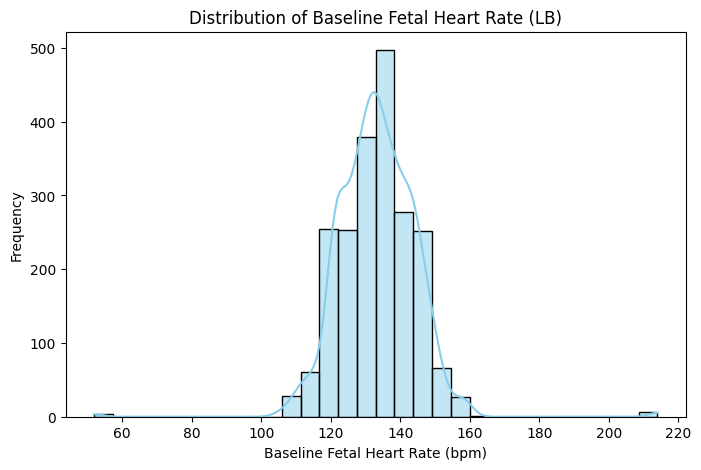

In [4]:
# 1. Histogram: Visualizing the distribution of Baseline Fetal Heart Rate (LB)
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['LB'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Baseline Fetal Heart Rate (LB)')
plt.xlabel('Baseline Fetal Heart Rate (bpm)')
plt.ylabel('Frequency')
plt.show()

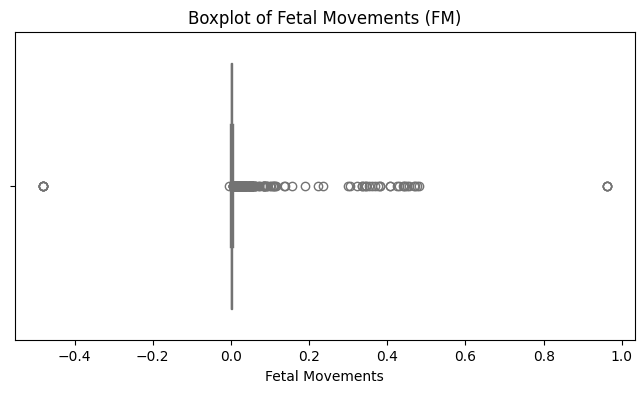

In [5]:
# 2. Boxplot: Checking for extreme values/outliers in Fetal Movements (FM)
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['FM'], color='lightgreen')
plt.title('Boxplot of Fetal Movements (FM)')
plt.xlabel('Fetal Movements')
plt.show()

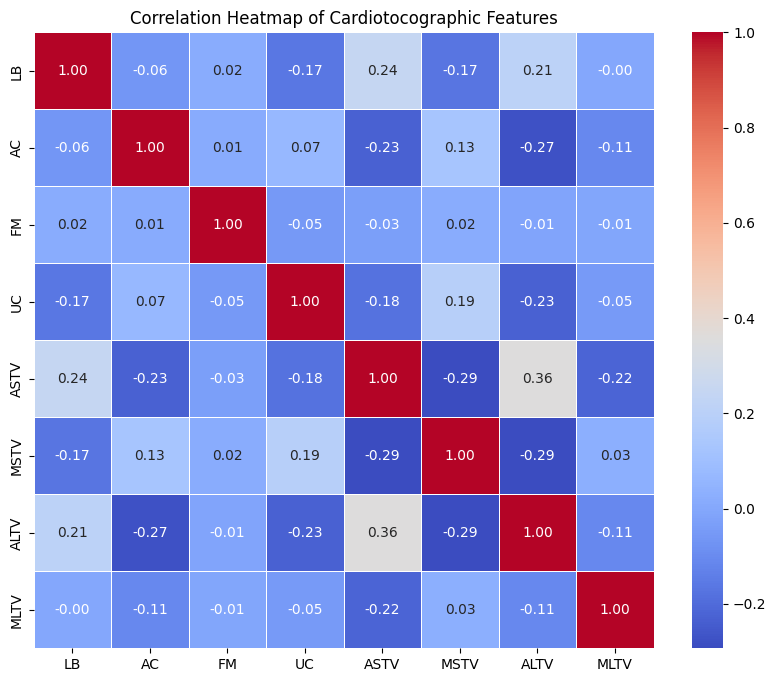

In [6]:
# 3. Correlation Heatmap: Seeing how different monitoring metrics relate to each other
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[['LB', 'AC', 'FM', 'UC', 'ASTV', 'MSTV', 'ALTV', 'MLTV']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Cardiotocographic Features')
plt.show()

Advanced Visualizations & Scatter Plots

1. Scatter Plot (Analysis of Relationships Between Two Variables)

What we are doing:

The Scatter Plot displays each data point on a two-dimensional graph, using an $X$ and $Y$ axis (for instance, plotting Baseline Fetal Heart Rate LB with respect to Accelerations AC).

Why we do it:

This procedure allows us to understand whether there is any relationship between two variables. The presence of a straight line indicates a linear relationship, while scattered points indicate there is no such thing.

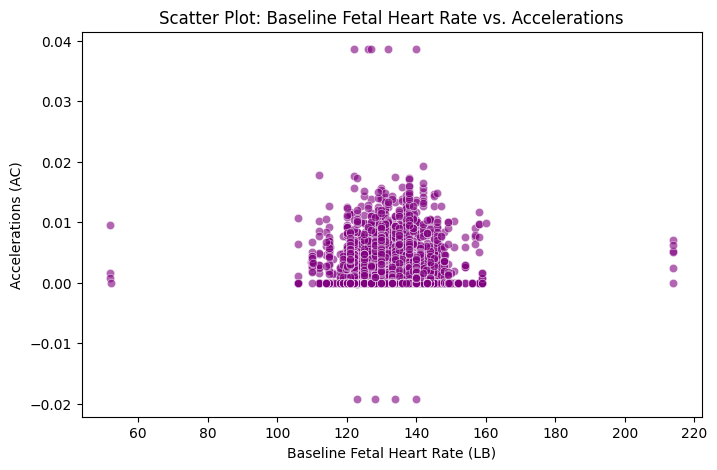

In [7]:
# Scatter Plot: Comparing Baseline Fetal Heart Rate (LB) vs. Accelerations (AC)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='LB', y='AC', color='purple', alpha=0.6)
plt.title('Scatter Plot: Baseline Fetal Heart Rate vs. Accelerations')
plt.xlabel('Baseline Fetal Heart Rate (LB)')
plt.ylabel('Accelerations (AC)')
plt.show()

2. Pair Plot (Ultimate Multi-Variable Exploring Tool)

What we are doing:

The pair plot is the creation of the matrix of the graphs where each numerical value in your data set is compared to any other values. The graph on the diagonal of the matrix will be a simple histogram of each variable.

Why we do it:

As a beginner, instead of writing hundreds of lines of code for individual graphs, you can look through all your dataset in one single plot.

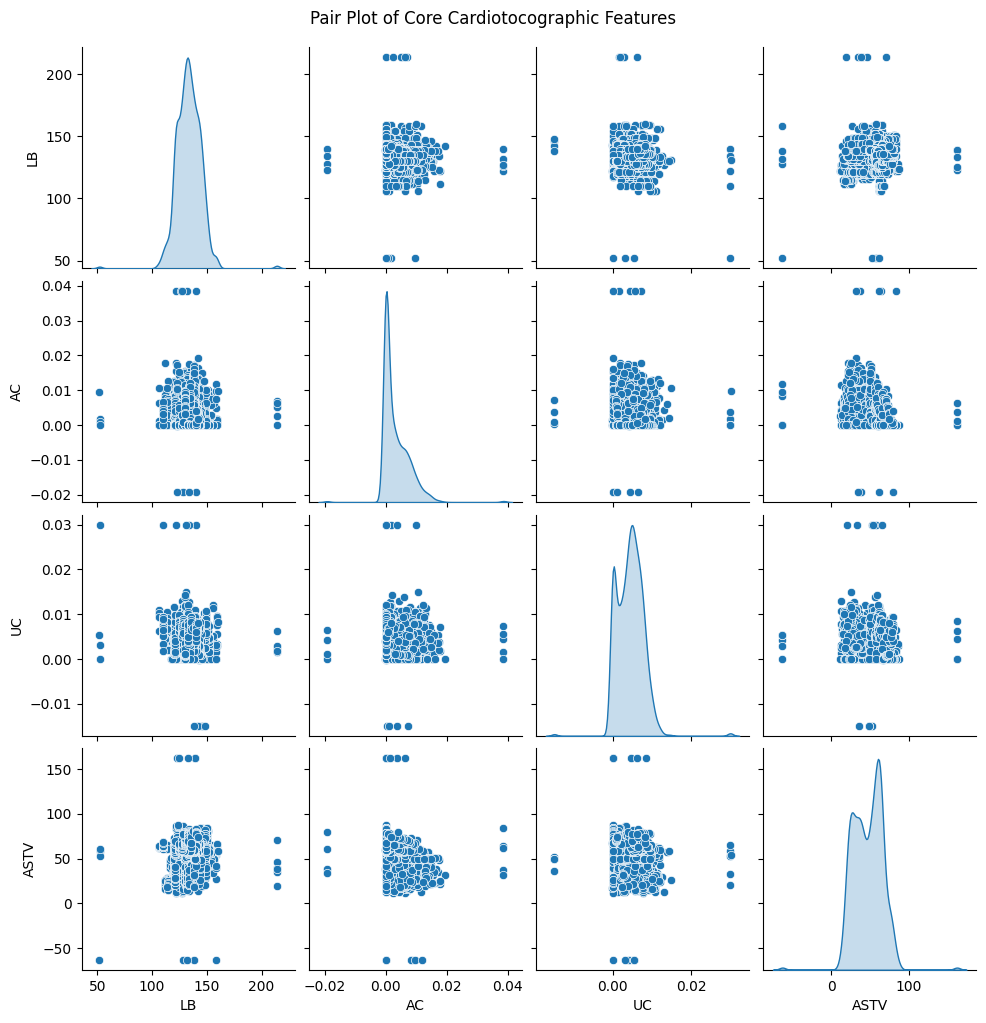

In [10]:
# Clean pair plot code without the warning
sns.pairplot(df_clean[['LB', 'AC', 'UC', 'ASTV']], diag_kind='kde')
plt.suptitle('Pair Plot of Core Cardiotocographic Features', y=1.02)
plt.show()

3. Violin Plot (Advanced Distribution & Density Plot)


What are we doing?

A violin plot consists of a combination of both the boxplot and the density plot. This plot allows us to view the shape of our distribution (the width/ narrowness of the values) along with the median and interquartile range of the dataset.

Why are we doing this?

Boxplots provide us with a graphical representation of summary statistics only, while violin plots allow us to view the full shape of our distribution, which can help us identify more than one peak/skew in our dataset.

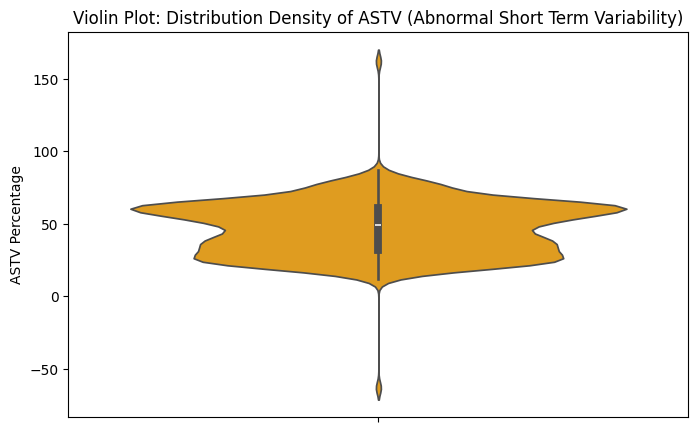

In [9]:
# Violin Plot: Visualizing the distribution density of Abnormal Short Term Variability (ASTV)
plt.figure(figsize=(8, 5))
sns.violinplot(y=df_clean['ASTV'], color='orange', inner='box')
plt.title('Violin Plot: Distribution Density of ASTV (Abnormal Short Term Variability)')
plt.ylabel('ASTV Percentage')
plt.show()

**Step 4: Pattern Recognition and Insights**

What are we doing?

We examine the patterns that emerge from the analysis of the heatmap and summary statistics.

Why are we doing this?

In medicine and data science, we need to know what the important signals are. In this example, you can see how AC and ASTV work. If the correlation is positive, it means the signals represent fetal health; otherwise, if there is an irregular variability or late deceleration (DL), it serves as a warning sign.

**Step 5: Conclusion and Business/Clinical Summary**

What we are doing:

We combine all our findings and come up with the summary.

Why we are doing it:

Exploratory data analysis is not only about visualizations but also about translating the data into actionable insight.

Key Finding:

The exploratory data analysis was successful in outlining the baseline values and heart rate variation for the monitor measurements.

Decision Implication:

 The findings confirm that monitoring certain variables such as abnormal short-term variability (ASTV) and accelerations (AC) could be used as basic features of the screening tools.

**Brief Report: Exploratory Data Analysis of Cardiotocographic Dataset**

1. Executive Summary

The current exploratory data analysis was carried out on the dataset Cardiotocographic.csv to study the features of heart rate of fetuses, uterine activity, and variability measures. The behavioral patterns have been found using the steps of data cleansing, statistical summaries, and multi-variable graphs.

2. Important Results & Insights
Baseline Stability (LB): The average baseline fetal heart rate value lies at approximately $133 \text{ bpm}$ and belongs to the physiological baseline stability range ($110\text{--}160\text{ bpm}$). The histogram distribution is quite symmetrical and balanced.

Well-Being Indicators (AC): The accelerations demonstrate positive correlation with the healthy baseline, which proves that fetal activity and heart rate increases are good indicators of well-being.

Variability and Risk Factors (ASTV, ALTV): Variables that are measuring abnormal short- and long-term variability have wide ranges. High values of abnormal variability (ASTV) are used as important warning signs for physicians about possible distress of fetus.

Correlation Insights: Scatterplots and correlation heatmaps demonstrate that variability variables and decelerations provide independent data from the baseline one.

3. Recommendations for Future Analysis & Actions

Construct Classification Prediction Model: As there are categorical health states (normal vs. pathology through NSP), the obvious future action would be to input all these features into predictive machine learning classification algorithms such as decision tree or random forest to predict fetal distress.

Advanced Outlier Handling: Although basic outlier handling was done to eliminate missing values, a possible further action would be to use isolation forest or advanced threshold bounding to deal with outliers in decelerations (DS, DP).

Decision Support System for Clinical Application: Hospitals can use knowledge about features such as ASTV and AC to construct automated decision support system for obstetricians based on critical cardiotocographic trace patterns.